In [1]:
p = 34
p

34

In [2]:
import os

In [3]:
%pwd

'd:\\Projects\\portfolio\\01-bias-audit\\research'

In [4]:
os.chdir("../")

In [5]:
%pwd

'd:\\Projects\\portfolio\\01-bias-audit'

In [6]:
# ── Cell 1 — imports & path setup ───────────────────────────────────
import sys, os

from pathlib import Path
import torch

from config.configuration import load_config
from src.constants import (
    MODEL_DIR,
    TOKENIZER_DIR,
    PROCESSED_DATA_FILE,
)
from src.utils import load_dataframe
from src import get_logger

logger = get_logger("research.prepare_base_model")
CONFIG = load_config()

print("✅ Imports successful")
print(f"   Model name     : {CONFIG.model.name}")
print(f"   Batch size     : {CONFIG.model.batch_size}")
print(f"   Max length     : {CONFIG.model.max_length}")
print(f"   Device         : {CONFIG.params.device}")
print(f"   Model save dir : {MODEL_DIR}")

✅ Imports successful
   Model name     : distilbert-base-uncased-finetuned-sst-2-english
   Batch size     : 32
   Max length     : 128
   Device         : cpu
   Model save dir : outputs\model


In [7]:
# ── Cell 2 — check GPU / CPU ─────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Torch version : {torch.__version__}")
print(f"Device        : {device}")

if device.type == "cuda":
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("Running on CPU — inference will be slow for large batches")
    print("Tip: reduce CONFIG.model.batch_size if memory errors occur")

Torch version : 2.11.0+cpu
Device        : cpu
Running on CPU — inference will be slow for large batches
Tip: reduce CONFIG.model.batch_size if memory errors occur


In [8]:
# ── Cell 3 — load tokenizer ──────────────────────────────────────────
from transformers import AutoTokenizer

try:
    logger.info(f"Loading tokenizer: {CONFIG.model.name}")
    tokenizer = AutoTokenizer.from_pretrained(CONFIG.model.name)

    print(f"Tokenizer loaded ✅")
    print(f"  Vocab size   : {tokenizer.vocab_size:,}")
    print(f"  Model max len: {tokenizer.model_max_length}")
    print(f"  Special tokens: {tokenizer.all_special_tokens}")

except OSError as e:
    logger.error(f"Tokenizer load failed — check model name or internet: {e}")
    raise

d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-05-05 20:43:35] INFO research.prepare_base_model - Loading tokenizer: distilbert-base-uncased-finetuned-sst-2-english


Tokenizer loaded ✅
  Vocab size   : 30,522
  Model max len: 512
  Special tokens: ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']


In [9]:
# ── Cell 4 — inspect tokenizer on sample inputs ──────────────────────
samples = [
    "age 39, education Bachelors, occupation Exec-managerial, hours 40",
    "age 52, education HS-grad, occupation Craft-repair, hours 45",
    "age 28, education Masters, occupation Prof-specialty, hours 60",
]

print("Sample tokenizations:\n")
for text in samples:
    enc = tokenizer(
        text,
        max_length=CONFIG.model.max_length,
        truncation=True,
        padding="max_length",
        return_tensors="pt"
    )
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    non_pad = [t for t in tokens if t != tokenizer.pad_token]
    print(f"  Input   : {text[:60]}...")
    print(f"  Tokens  : {non_pad}")
    print(f"  Length  : {enc['input_ids'].shape[1]}")
    print()

Sample tokenizations:

  Input   : age 39, education Bachelors, occupation Exec-managerial, hou...
  Tokens  : ['[CLS]', 'age', '39', ',', 'education', 'bachelor', '##s', ',', 'occupation', 'ex', '##ec', '-', 'managerial', ',', 'hours', '40', '[SEP]']
  Length  : 128

  Input   : age 52, education HS-grad, occupation Craft-repair, hours 45...
  Tokens  : ['[CLS]', 'age', '52', ',', 'education', 'hs', '-', 'gr', '##ad', ',', 'occupation', 'craft', '-', 'repair', ',', 'hours', '45', '[SEP]']
  Length  : 128

  Input   : age 28, education Masters, occupation Prof-specialty, hours ...
  Tokens  : ['[CLS]', 'age', '28', ',', 'education', 'masters', ',', 'occupation', 'prof', '-', 'specialty', ',', 'hours', '60', '[SEP]']
  Length  : 128



In [10]:
# ── Cell 5 — load model ──────────────────────────────────────────────
from transformers import AutoModelForSequenceClassification

try:
    logger.info(f"Loading model: {CONFIG.model.name}")
    model = AutoModelForSequenceClassification.from_pretrained(
        CONFIG.model.name,
        num_labels=2,
        ignore_mismatched_sizes=True,
    )
    model = model.to(device)
    model.eval()

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Model loaded ✅")
    print(f"  Architecture    : {model.config.model_type}")
    print(f"  Total params    : {total_params:,}")
    print(f"  Trainable params: {trainable_params:,}")
    print(f"  Num labels      : {model.config.num_labels}")
    print(f"  Hidden size     : {model.config.hidden_size}")

except OSError as e:
    logger.error(f"Model load failed: {e}")
    raise
except RuntimeError as e:
    logger.error(f"Runtime error — try reducing batch size or switching to CPU: {e}")
    raise

[2026-05-05 20:44:48] INFO research.prepare_base_model - Loading model: distilbert-base-uncased-finetuned-sst-2-english


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2527.48it/s]


Model loaded ✅
  Architecture    : distilbert
  Total params    : 66,955,010
  Trainable params: 66,955,010
  Num labels      : 2
  Hidden size     : 768


In [11]:
# ── Cell 6 — single sample inference test ────────────────────────────
import torch.nn.functional as F

test_text = "age 45, education Bachelors, occupation Exec-managerial, hours 50"

try:
    enc = tokenizer(
        test_text,
        max_length=CONFIG.model.max_length,
        truncation=True,
        padding="max_length",
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**enc)

    logits = outputs.logits
    probs  = F.softmax(logits, dim=-1)
    pred   = torch.argmax(probs, dim=-1).item()
    label  = ">50K" if pred == 1 else "<=50K"

    print(f"Input text   : {test_text}")
    print(f"Logits       : {logits.cpu().numpy()}")
    print(f"Probabilities: <=50K={probs[0][0]:.4f}  >50K={probs[0][1]:.4f}")
    print(f"Prediction   : {pred} → {label}")
    logger.info("Single sample inference ✅")

except Exception as e:
    logger.error(f"Inference failed: {e}")
    raise

Input text   : age 45, education Bachelors, occupation Exec-managerial, hours 50
Logits       : [[-0.46422848  0.44456053]]
Probabilities: <=50K=0.2872  >50K=0.7128
Prediction   : 1 → >50K
[2026-05-05 20:45:16] INFO research.prepare_base_model - Single sample inference ✅


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\rajve\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\logging\__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
  File "C:\Users\rajve\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 81: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    ap

In [12]:
# ── Cell 7 — batch inference on processed dataset ─────────────────────
import pandas as pd
from torch.utils.data import DataLoader, Dataset

class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length):
        self.encodings = tokenizer(
            texts,
            max_length=max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        )
    def __len__(self):
        return self.encodings["input_ids"].shape[0]
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}

try:
    if not Path(PROCESSED_DATA_FILE).exists():
        raise FileNotFoundError(
            f"Processed data not found: {PROCESSED_DATA_FILE}\n"
            "  → Run data_ingestion.ipynb first"
        )

    df = load_dataframe(str(PROCESSED_DATA_FILE))
    logger.info(f"Loaded {len(df):,} rows for inference")

    # build text representation per row
    df["text"] = df.apply(
        lambda r: (
            f"age {r['age']}, education {r['education']}, "
            f"occupation {r['occupation']}, "
            f"hours {r['hours.per.week']}, "
            f"sex {r['sex']}, race {r['race']}"
        ),
        axis=1
    )

    # limit to 500 rows for research — full run belongs in pipeline
    sample_df = df.sample(500, random_state=42).reset_index(drop=True)
    logger.info(f"Running inference on {len(sample_df)} sample rows...")

    dataset    = TextDataset(sample_df["text"].tolist(), tokenizer, CONFIG.model.max_length)
    dataloader = DataLoader(dataset, batch_size=CONFIG.model.batch_size)

    all_preds, all_probs = [], []

    model.eval()
    with torch.no_grad():
        for batch in dataloader:
            batch   = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            probs   = F.softmax(outputs.logits, dim=-1)
            preds   = torch.argmax(probs, dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_probs.extend(probs[:, 1].cpu().tolist())

    sample_df["prediction"] = all_preds
    sample_df["prob_gt50k"] = all_probs

    print(f"Inference complete ✅ — {len(sample_df)} rows")
    print(sample_df[["text", "income", "prediction", "prob_gt50k"]].head(8).to_string())

except FileNotFoundError as e:
    logger.error(f"File not found: {e}")
    print(f"\n❌ {e}")
except RuntimeError as e:
    logger.error(f"Inference runtime error: {e}")
    print(f"\n❌ RuntimeError: {e}\n   Try reducing batch_size in config")
except Exception as e:
    logger.exception(f"Unexpected error during batch inference: {e}")
    raise

[2026-05-05 20:45:23] INFO src.utils.common - DataFrame loaded: data\processed\clean.csv — shape: (30162, 15)
[2026-05-05 20:45:23] INFO research.prepare_base_model - Loaded 30,162 rows for inference
[2026-05-05 20:45:27] INFO research.prepare_base_model - Running inference on 500 sample rows...
Inference complete ✅ — 500 rows
                                                                                                    text  income  prediction  prob_gt50k
0     age 45, education Assoc-acdm, occupation Adm-clerical, hours 40, sex Male, race Asian-Pac-Islander       0           0    0.085206
1                  age 22, education HS-grad, occupation Farming-fishing, hours 40, sex Male, race White       0           0    0.418023
2                 age 39, education Bachelors, occupation Adm-clerical, hours 40, sex Female, race White       0           0    0.199895
3  age 35, education Prof-school, occupation Prof-specialty, hours 40, sex Male, race Asian-Pac-Islander       1           

Classification Report (sample — 500 rows):

              precision    recall  f1-score   support

       <=50K       0.74      0.98      0.84       369
        >50K       0.18      0.02      0.03       131

    accuracy                           0.72       500
   macro avg       0.46      0.50      0.43       500
weighted avg       0.59      0.72      0.63       500



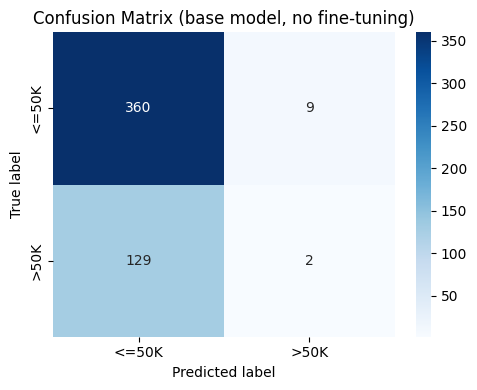

[2026-05-05 20:50:05] INFO research.prepare_base_model - Baseline evaluation complete ✅


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\rajve\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\logging\__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
  File "C:\Users\rajve\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 86: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    ap

In [13]:
# ── Cell 8 — baseline accuracy on sample ─────────────────────────────
try:
    from sklearn.metrics import classification_report, confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    y_true = sample_df["income"].tolist()
    y_pred = sample_df["prediction"].tolist()

    print("Classification Report (sample — 500 rows):\n")
    print(classification_report(y_true, y_pred, target_names=["<=50K", ">50K"]))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["<=50K", ">50K"],
                yticklabels=["<=50K", ">50K"])
    plt.title("Confusion Matrix (base model, no fine-tuning)")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

    logger.info("Baseline evaluation complete ✅")

except Exception as e:
    logger.error(f"Evaluation error: {e}")
    raise

In [14]:
# ── Cell 9 — save model & tokenizer ──────────────────────────────────
try:
    model_path     = Path(MODEL_DIR)
    tokenizer_path = Path(TOKENIZER_DIR)

    model_path.mkdir(parents=True, exist_ok=True)
    tokenizer_path.mkdir(parents=True, exist_ok=True)

    model.save_pretrained(str(model_path))
    tokenizer.save_pretrained(str(tokenizer_path))

    model_size_mb = sum(
        f.stat().st_size for f in model_path.rglob("*") if f.is_file()
    ) / (1024 ** 2)

    print(f"Model saved     → {model_path}  ({model_size_mb:.1f} MB)")
    print(f"Tokenizer saved → {tokenizer_path}")
    logger.info(f"Model and tokenizer saved ✅")

except PermissionError as e:
    logger.error(f"Permission denied when saving: {e}")
    raise
except OSError as e:
    logger.error(f"OS error during save: {e}")
    raise
except Exception as e:
    logger.exception(f"Unexpected error saving model: {e}")
    raise

Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.52s/it]


Model saved     → outputs\model  (255.4 MB)
Tokenizer saved → outputs\tokenizer
[2026-05-05 20:50:37] INFO research.prepare_base_model - Model and tokenizer saved ✅


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\rajve\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\logging\__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
  File "C:\Users\rajve\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 83: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    ap

In [15]:
# ── Cell 10 — summary ────────────────────────────────────────────────
try:
    if not Path(MODEL_DIR).exists():
        raise FileNotFoundError(
            f"Model directory not found: {MODEL_DIR}\n"
            "  → Re-run Cell 9 to save the model"
        )

    if "model" not in dir() or model is None:
        raise NameError("model not in memory — re-run Cell 5")

    if "sample_df" not in dir() or sample_df is None:
        raise NameError("sample_df not in memory — re-run Cell 7")

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    accuracy         = (sample_df["income"] == sample_df["prediction"]).mean()

    print("=" * 55)
    print("   PREPARE BASE MODEL RESEARCH — SUMMARY")
    print("=" * 55)
    print(f"  Model name       : {CONFIG.model.name}")
    print(f"  Architecture     : {model.config.model_type}")
    print(f"  Total params     : {total_params:,}")
    print(f"  Trainable params : {trainable_params:,}")
    print(f"  Device           : {device}")
    print(f"  Sample rows      : {len(sample_df):,}")
    print(f"  Baseline accuracy: {accuracy:.4f}  ({accuracy*100:.1f}%)")
    print(f"  Model saved to   : {MODEL_DIR}")
    print(f"  Tokenizer saved  : {TOKENIZER_DIR}")
    print("=" * 55)

    if accuracy < 0.60:
        logger.warning(
            f"Baseline accuracy {accuracy:.2%} is low — "
            "model likely needs fine-tuning before bias metrics are meaningful"
        )
    else:
        logger.info(f"Baseline accuracy {accuracy:.2%} ✅")

    logger.info("Prepare base model research complete ✅")
    print("\n  Next → open prepare_callbacks.ipynb")

except FileNotFoundError as e:
    logger.error(f"File not found: {e}")
    print(f"\n❌ FileNotFoundError: {e}")
except NameError as e:
    logger.error(f"Variable missing from memory: {e}")
    print(f"\n❌ NameError: {e}")
except KeyError as e:
    logger.error(f"Column missing from DataFrame: {e}")
    print(f"\n❌ KeyError: {e}")
    print(f"   Available columns: {sample_df.columns.tolist()}")
except Exception as e:
    logger.exception(f"Unexpected error in summary cell: {e}")
    print(f"\n❌ Unexpected error: {type(e).__name__}: {e}")
    print("   Check logs/ for full traceback")

   PREPARE BASE MODEL RESEARCH — SUMMARY
  Model name       : distilbert-base-uncased-finetuned-sst-2-english
  Architecture     : distilbert
  Total params     : 66,955,010
  Trainable params : 66,955,010
  Device           : cpu
  Sample rows      : 500
  Baseline accuracy: 0.7240  (72.4%)
  Model saved to   : outputs\model
  Tokenizer saved  : outputs\tokenizer
[2026-05-05 20:50:46] INFO research.prepare_base_model - Baseline accuracy 72.40% ✅
[2026-05-05 20:50:46] INFO research.prepare_base_model - Prepare base model research complete ✅

  Next → open prepare_callbacks.ipynb


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\rajve\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\logging\__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
  File "C:\Users\rajve\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 82: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    ap